# Exoplanet Detection
---  
> Classifying Kepler observations as confirmed exoplanets, false positives, or candidates.

| Label | Class | Description |
| :---: | :---: | :--- |
| 0 | FALSE POSITIVE | Not a real exoplanet |
| 1 | CANDIDATE | Potential exoplanet, awaiting confirmation |
| 2 | CONFIRMED | Verified exoplanet |

**Dataset:** [Kepler Exoplanet Dataset on Kaggle](https://www.kaggle.com/datasets/gauravkumar2525/kepler-exoplanet-dataset)

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import RobustScaler
from sklearn.impute import IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

## confusion matrix helper

In [78]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('actual')
    plt.xlabel('predicted')
    plt.show()

## load data

In [ ]:
data = pd.read_csv('data/exoplanets_data.csv')
data = data.drop(columns=['kepid', 'kepoi_name'])   # non-informative identifiers
data = data.dropna(subset=['koi_disposition'])       # drop rows with no label
data['koi_disposition'] = data['koi_disposition'].astype(int)
# 0 = FALSE POSITIVE, 1 = CANDIDATE, 2 = CONFIRMED

print(f"data shape: {data.shape}")
print(data['koi_disposition'].value_counts())

data shape: (9564, 10)
koi_disposition
0    4839
2    2743
1    1982
Name: count, dtype: int64


## split

In [80]:
y = data['koi_disposition']
X = data.drop(columns=['koi_disposition'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (7651, 9), test: (1913, 9)


## feature engineering

In [81]:
X_train = X_train.copy()
X_test = X_test.copy()

# score weighted by period
X_train['score_period'] = X_train['koi_score'] * X_train['koi_period']
X_test['score_period'] = X_test['koi_score'] * X_test['koi_period']

# planet to stellar radius ratio
X_train['radius_ratio'] = X_train['koi_prad'] / (X_train['koi_srad'] + 1e-5)
X_test['radius_ratio'] = X_test['koi_prad'] / (X_test['koi_srad'] + 1e-5)

# score squared
X_train['score_sq'] = X_train['koi_score'] ** 2
X_test['score_sq'] = X_test['koi_score'] ** 2

# equilibrium to stellar temperature ratio
X_train['temp_ratio'] = X_train['koi_teq'] / (X_train['koi_steff'] + 1e-5)
X_test['temp_ratio'] = X_test['koi_teq'] / (X_test['koi_steff'] + 1e-5)

## data preprocessing

In [82]:
# log transform skewed columns
log_cols = ['koi_period', 'koi_insol', 'koi_prad', 'koi_srad']
for col in log_cols:
    X_train[col] = np.log1p(X_train[col].clip(lower=0))
    X_test[col] = np.log1p(X_test[col].clip(lower=0))

# imputation
imputer = IterativeImputer(max_iter=10, random_state=42)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

# scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled  = scaler.transform(X_test_imputed)

# handling imbalance
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f"resampled shape: {X_train_res.shape}")

resampled shape: (11613, 13)


## baseline model: decision tree

decision tree classification report
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       968
           1       0.45      0.54      0.49       396
           2       0.78      0.72      0.75       549

    accuracy                           0.75      1913
   macro avg       0.71      0.71      0.70      1913
weighted avg       0.77      0.75      0.76      1913



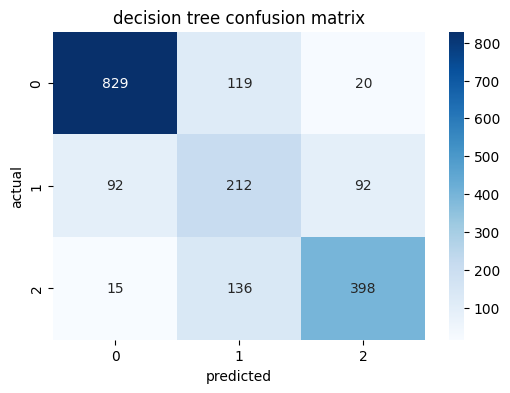

In [83]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train_res, y_train_res)

y_pred_dt = dt.predict(X_test_scaled)
print("decision tree classification report")
print(classification_report(y_test, y_pred_dt, zero_division=0))
plot_cm(y_test, y_pred_dt, 'decision tree confusion matrix')

## primary model: xgboost

tuning xgboost...
best params: {'subsample': 0.85, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
xgboost classification report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       968
           1       0.55      0.57      0.56       396
           2       0.84      0.81      0.83       549

    accuracy                           0.80      1913
   macro avg       0.76      0.76      0.76      1913
weighted avg       0.81      0.80      0.80      1913



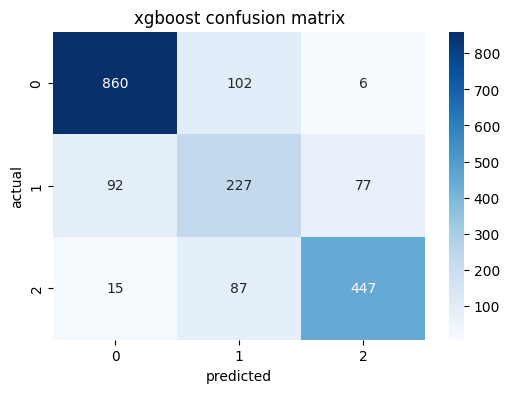

In [86]:
print("tuning xgboost...")

param_dist = {
    'n_estimators': [300, 500, 800],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_dist, n_iter=40, cv=cv,
    scoring='f1_macro',
    n_jobs=-1, random_state=42
)
search.fit(X_train_res, y_train_res)

best_xgb = search.best_estimator_
print("best params:", search.best_params_)

y_pred_xgb = best_xgb.predict(X_test_scaled)
print("xgboost classification report")
print(classification_report(y_test, y_pred_xgb))
plot_cm(y_test, y_pred_xgb, 'xgboost confusion matrix')

## ensemble model

ensemble classification report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       968
           1       0.56      0.60      0.58       396
           2       0.85      0.81      0.83       549

    accuracy                           0.81      1913
   macro avg       0.77      0.77      0.77      1913
weighted avg       0.81      0.81      0.81      1913



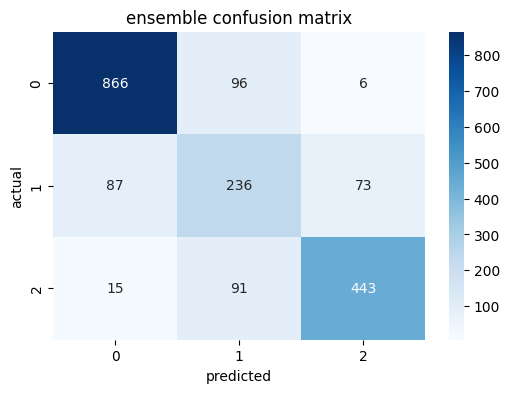

In [87]:
# soft voting, combines xgb and rf probability estimates
ensemble = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('rf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)),
    ],
    voting='soft'
)

ensemble.fit(X_train_res, y_train_res)
y_pred_ens = ensemble.predict(X_test_scaled)
print("ensemble classification report")
print(classification_report(y_test, y_pred_ens))
plot_cm(y_test, y_pred_ens, 'ensemble confusion matrix')

## binary classification

binary classification report (FALSE POSITIVE vs CONFIRMED)
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       968
           1       0.97      0.96      0.97       549

    accuracy                           0.98      1517
   macro avg       0.97      0.97      0.97      1517
weighted avg       0.98      0.98      0.98      1517



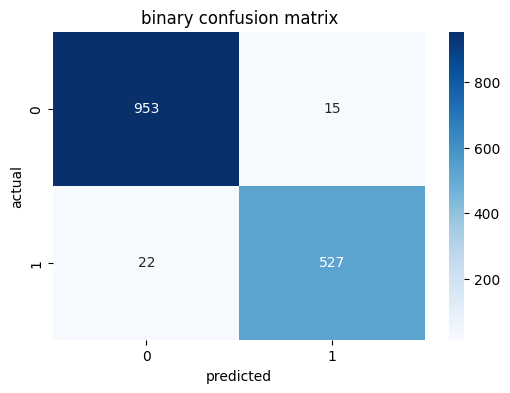

In [85]:
# binary classification
# # candidate class excluded, too ambiguous to classify cleanly
mask_train = y_train_res != 1
mask_test = y_test != 1

X_binary_train = X_train_res[mask_train]
y_binary_train = (y_train_res[mask_train] == 2).astype(int)

X_binary_test = X_test_scaled[mask_test]
y_binary_test = (y_test[mask_test] == 2).astype(int)

xgb_binary = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_binary.fit(X_binary_train, y_binary_train)

y_pred_binary = xgb_binary.predict(X_binary_test)
print("binary classification report (FALSE POSITIVE vs CONFIRMED)")
print(classification_report(y_binary_test, y_pred_binary))
plot_cm(y_binary_test, y_pred_binary, 'binary confusion matrix')